In [11]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import json

from model.architecture.basic_siamese_model import BasicSiameseModel
from model.architecture.advanced_siamese_model import AdvancedSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from utils.phase import Phase
from visualization.data.weights_visualizator import WeightsVisualizator
from visualization.results.metrics_visualizator import MetricsVisualizator
from metrics.evaluator import Evaluator
from analytic_methods.EVM_method import EVM

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cpu


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4]

TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

MODEL_TYPE = "siamese"
MODEL_NAME = "basic_10000m"

In [4]:
def load_test_matrices(loader: MatricesLoader):
    all_matrices = {}
    all_weights = {}

    for cr in CONSISTENCY_RATES:
        matrices, weights = loader.load_noisy_cr_matrices(Phase.TEST, cr, IS_UNIFORM, CRITERIA_NUM, TEST_MATRICES_NUM)
        all_matrices[cr] = matrices
        all_weights[cr] = weights

    print(f"{len(list(all_matrices.keys())) * TEST_MATRICES_NUM} matrices and weights with different cr was successfully uploaded")
    return all_matrices, all_weights


def load_model_weights_history(model: torch.nn.Module, model_type_name: str, name: str, 
                               device: torch.device) -> tuple[torch.nn.Module, dict[str, list]]:
    base_dir = "models"
    dir_path = os.path.join(base_dir, model_type_name)
    model_path = os.path.join(dir_path, f"model_{name}.pth")
    history_path = os.path.join(dir_path, f"history_{name}.json")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")
    
    if not os.path.exists(history_path):
        raise FileNotFoundError(f"History file not found: {history_path}")

    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    with open(history_path, "r", encoding="utf-8") as file:
        history = json.load(file)
    
    print(f"History and model: {name} was loaded from {dir_path}")
    return model, history

In [5]:
def predict_single_weights(model: torch.nn.Module, matrix: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()

    tensor_matrix = torch.tensor(matrix, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrix + 1e-8)
    tensor_input = tensor_log.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights = weights.squeeze(0).cpu().numpy()
    return final_weights


def predict_batch_weights(model: torch.nn.Module, matrices: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()

    tensor_matrices = torch.tensor(matrices, dtype=torch.float32).to(device)
    tensor_log = torch.log(tensor_matrices + 1e-8)
    tensor_input = tensor_log.unsqueeze(1)

    with torch.no_grad():
        logits = model.encoder(tensor_input)
        weights = F.softmax(logits, dim=1)

    final_weights_batch = weights.cpu().numpy()
    return final_weights_batch

In [ ]:
model = BasicSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

History and model: basic_10000m was loaded from models/siamese
20000 matrices and weights with different cr was successfully uploaded
Predicted AHP weights


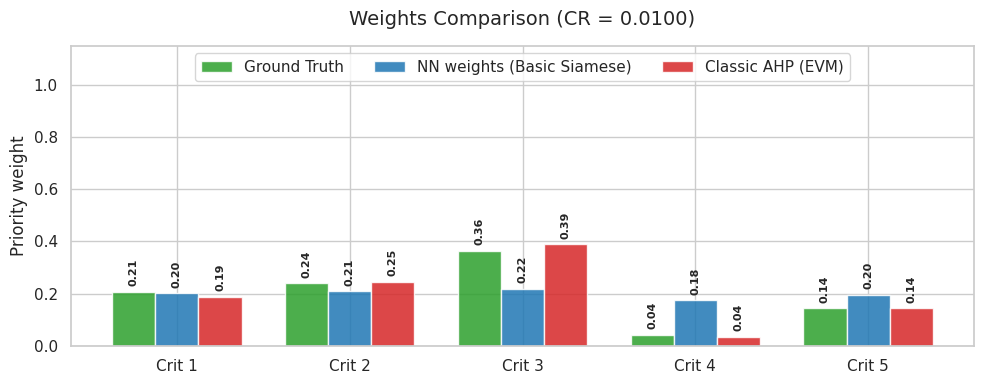

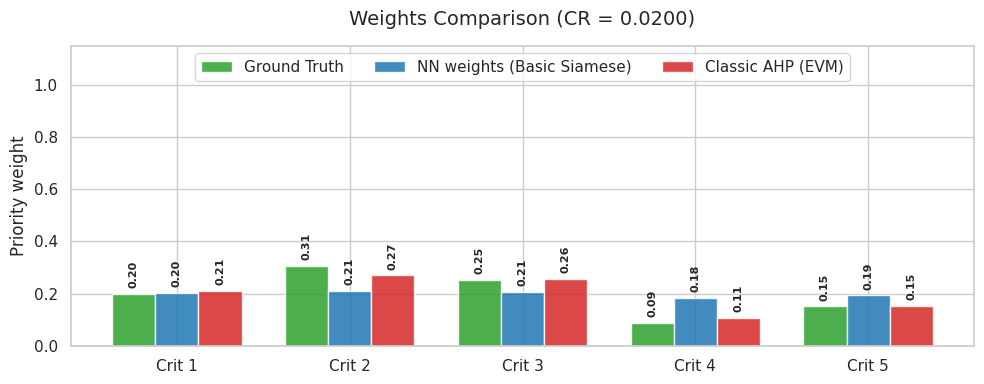

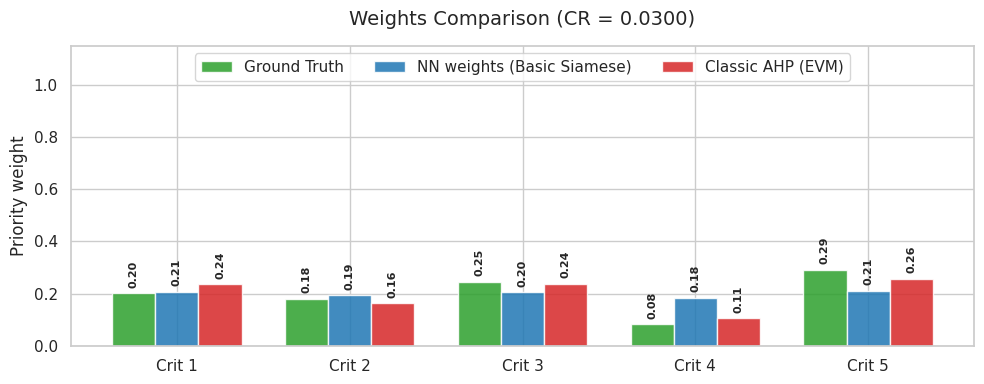

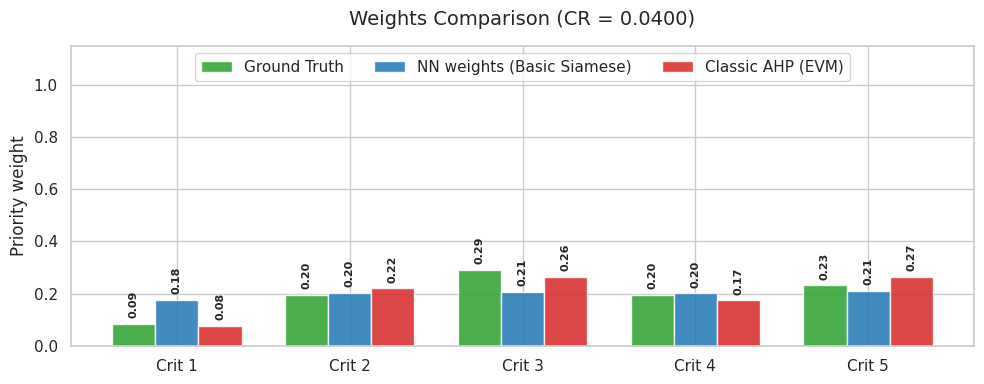

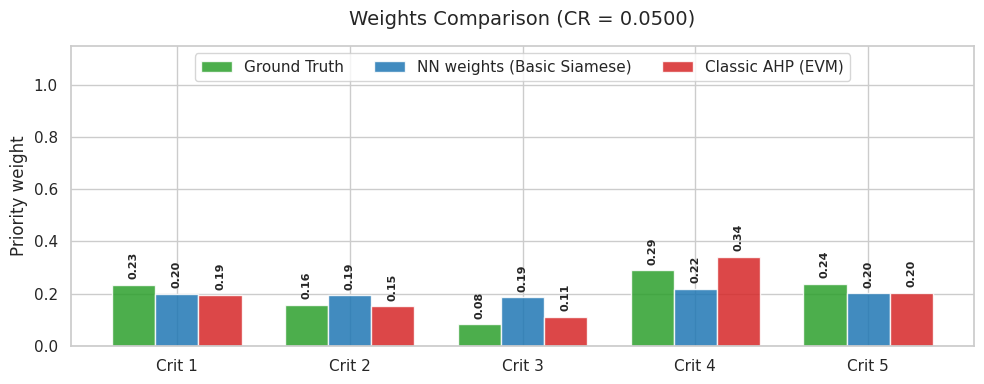

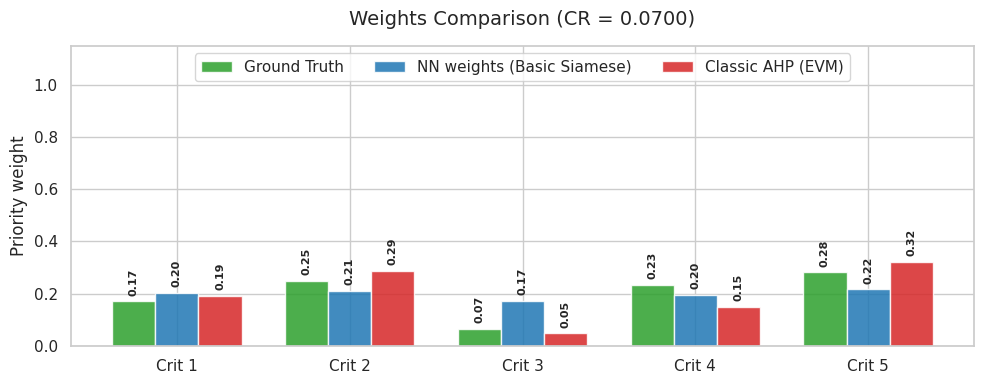

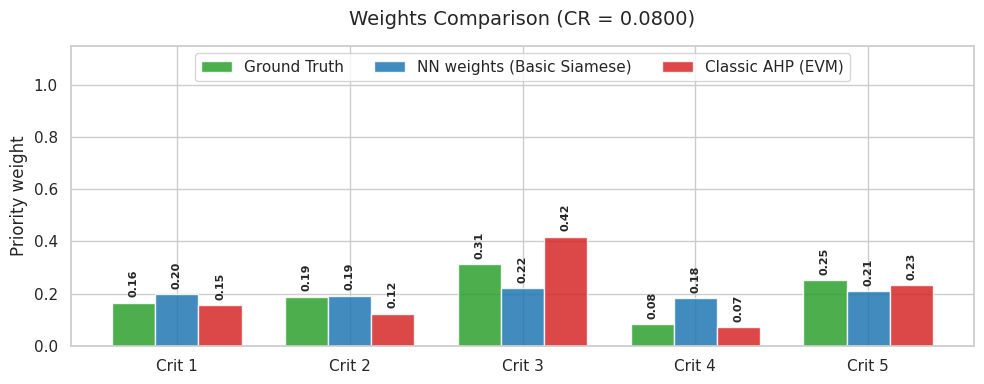

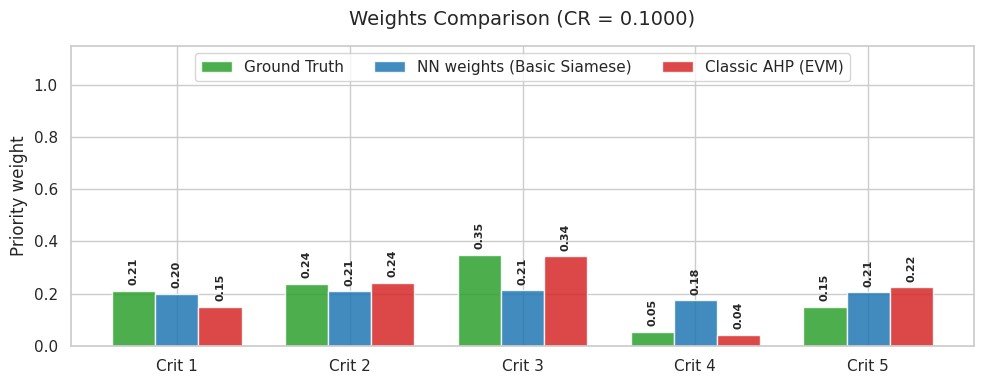

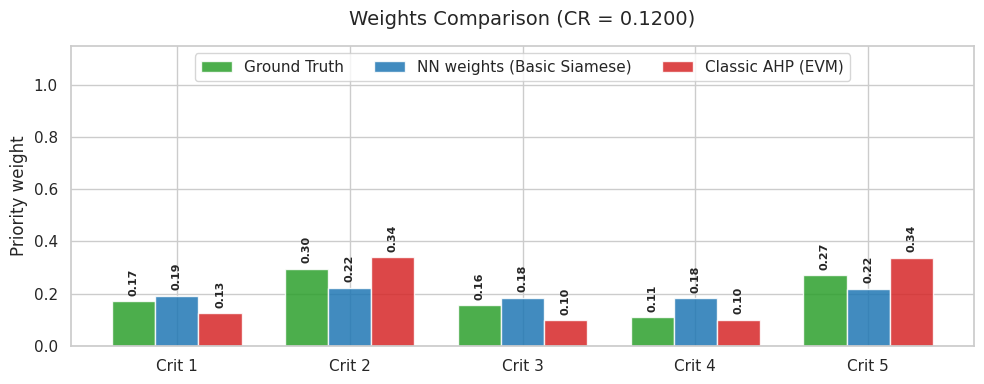

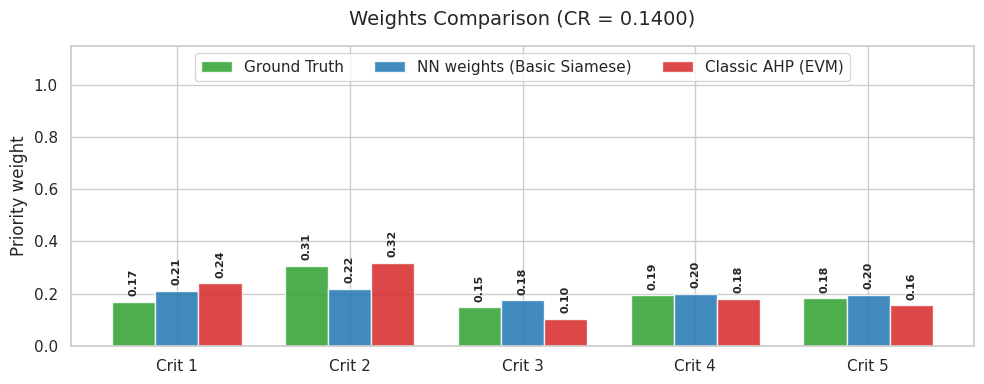

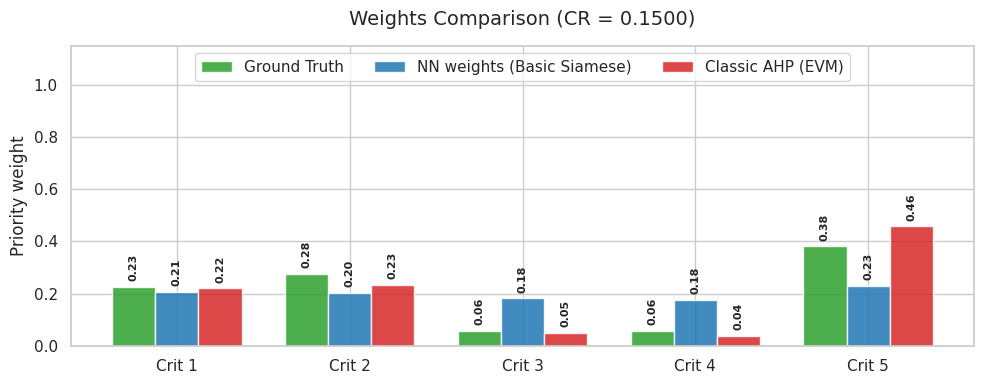

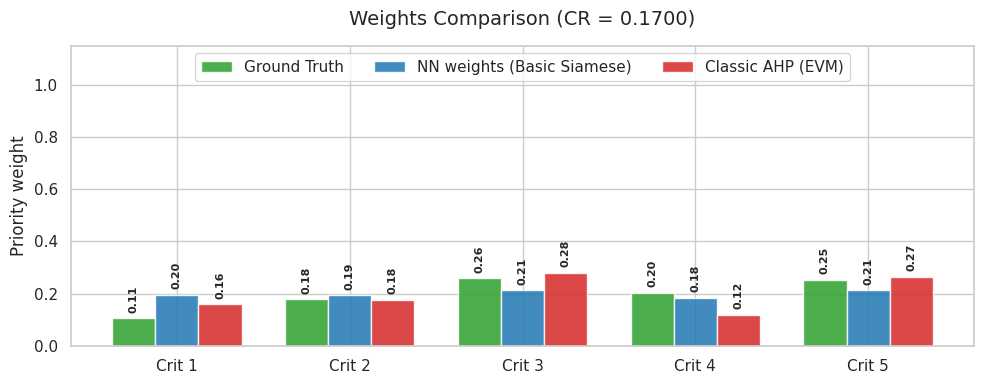

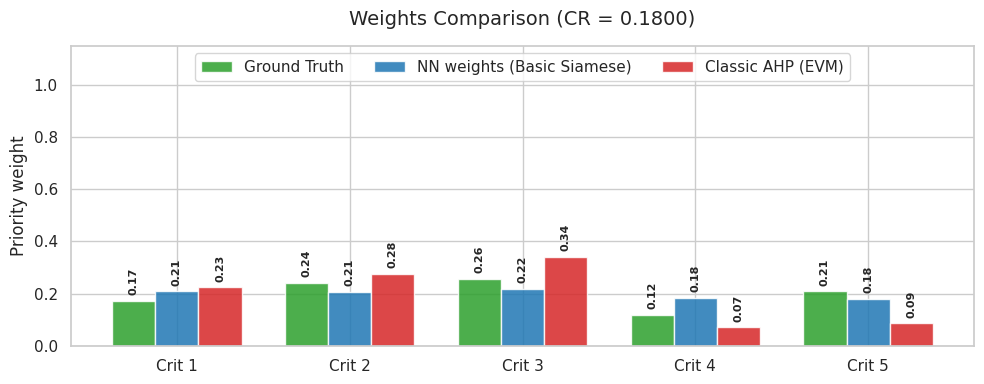

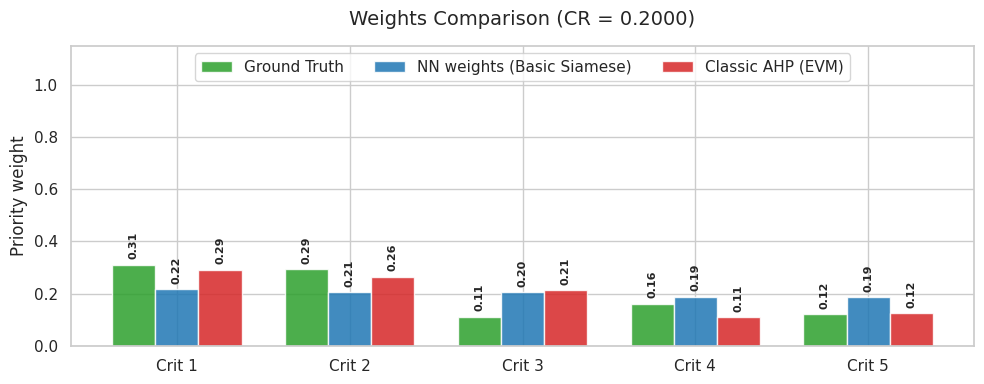

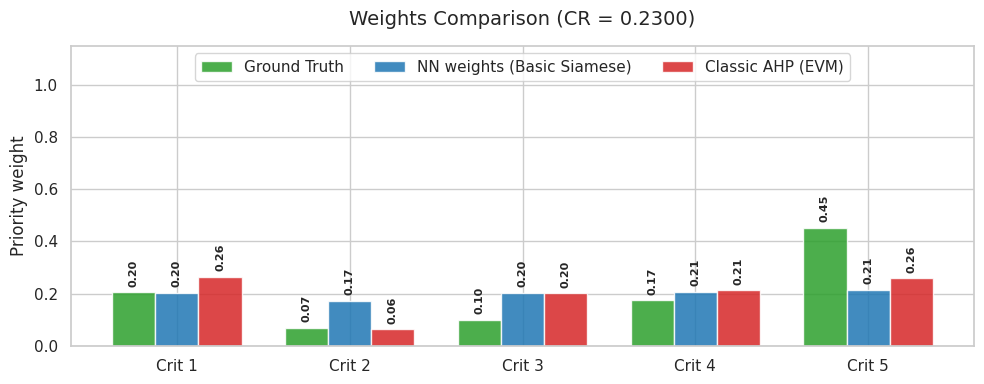

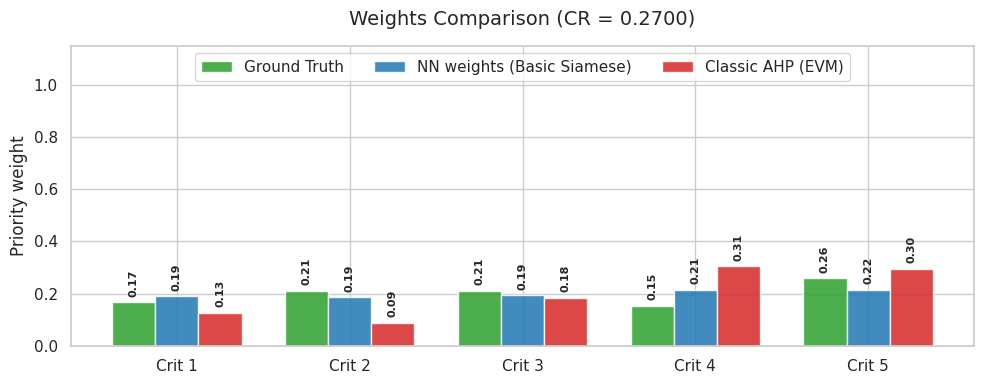

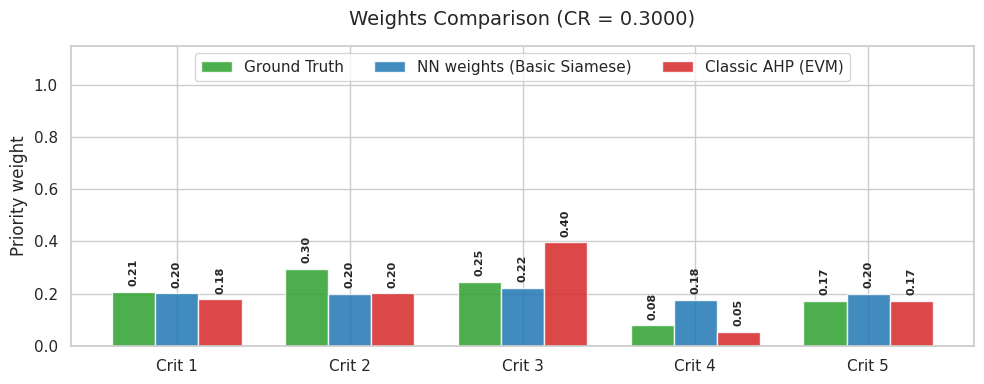

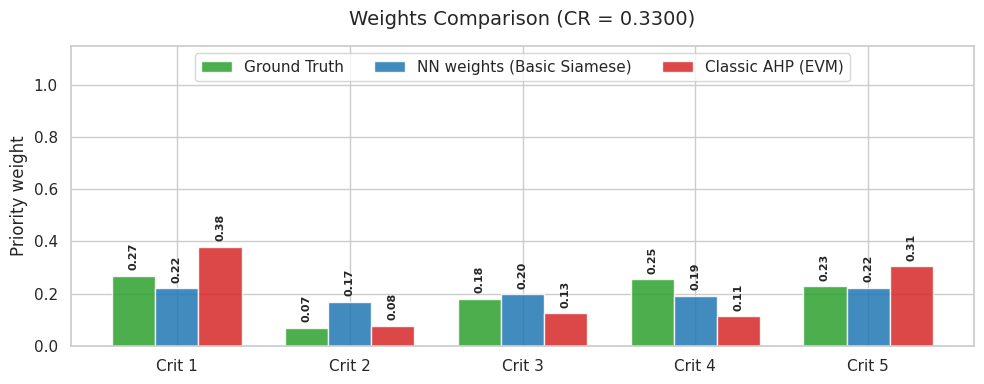

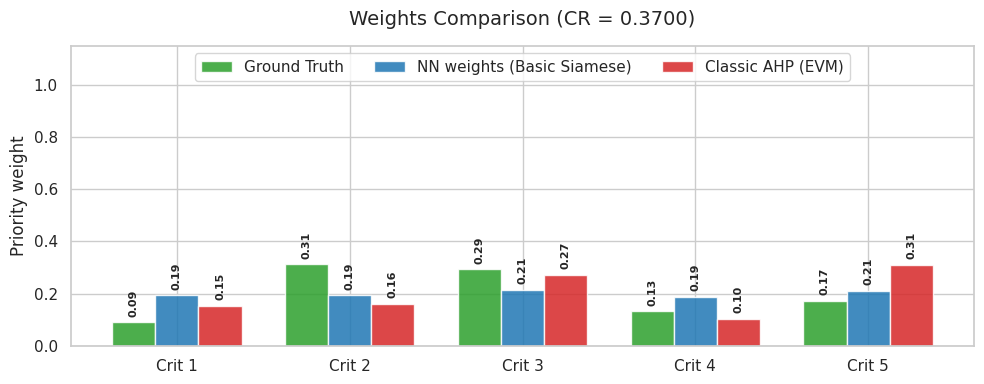

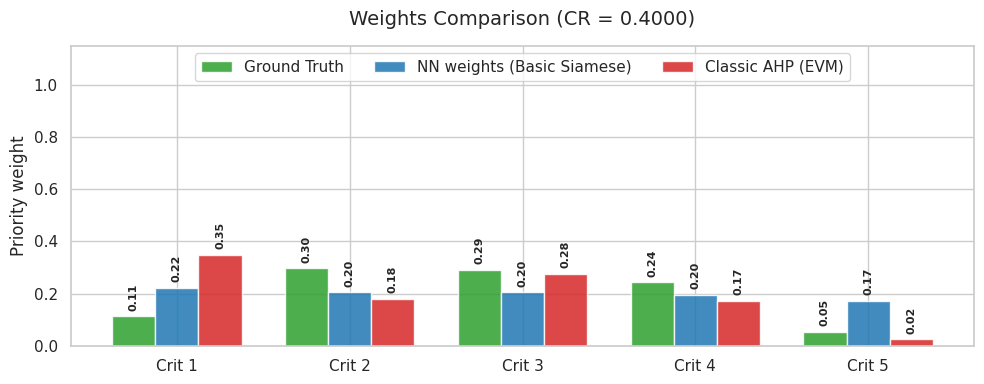

In [7]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)

In [8]:
def compare_results_single(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrix, weights_vector, pred_weights_vector in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vector, _ = solver.compute_single(test_matrix)
        mae_evm, kendall_taus_evm = evaluator.evaluate_single(weights_vector, evm_weights_vector)
        mae_nn, kendal_taus_nn = evaluator.evaluate_single(weights_vector, pred_weights_vector)

        all_mae_evm.append(mae_evm)
        all_kendall_taus_evm.append(kendall_taus_evm)
        all_mae_nn.append(mae_nn)
        all_kendall_taus_nn.append(kendal_taus_nn)

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 20 consistency rates.
Global mean CR: 0.1630
Global mean MAE (EVM): 0.0499, NN: 0.0646
Global mean Kendall correlation (EVM): 0.6368, NN: 0.6292


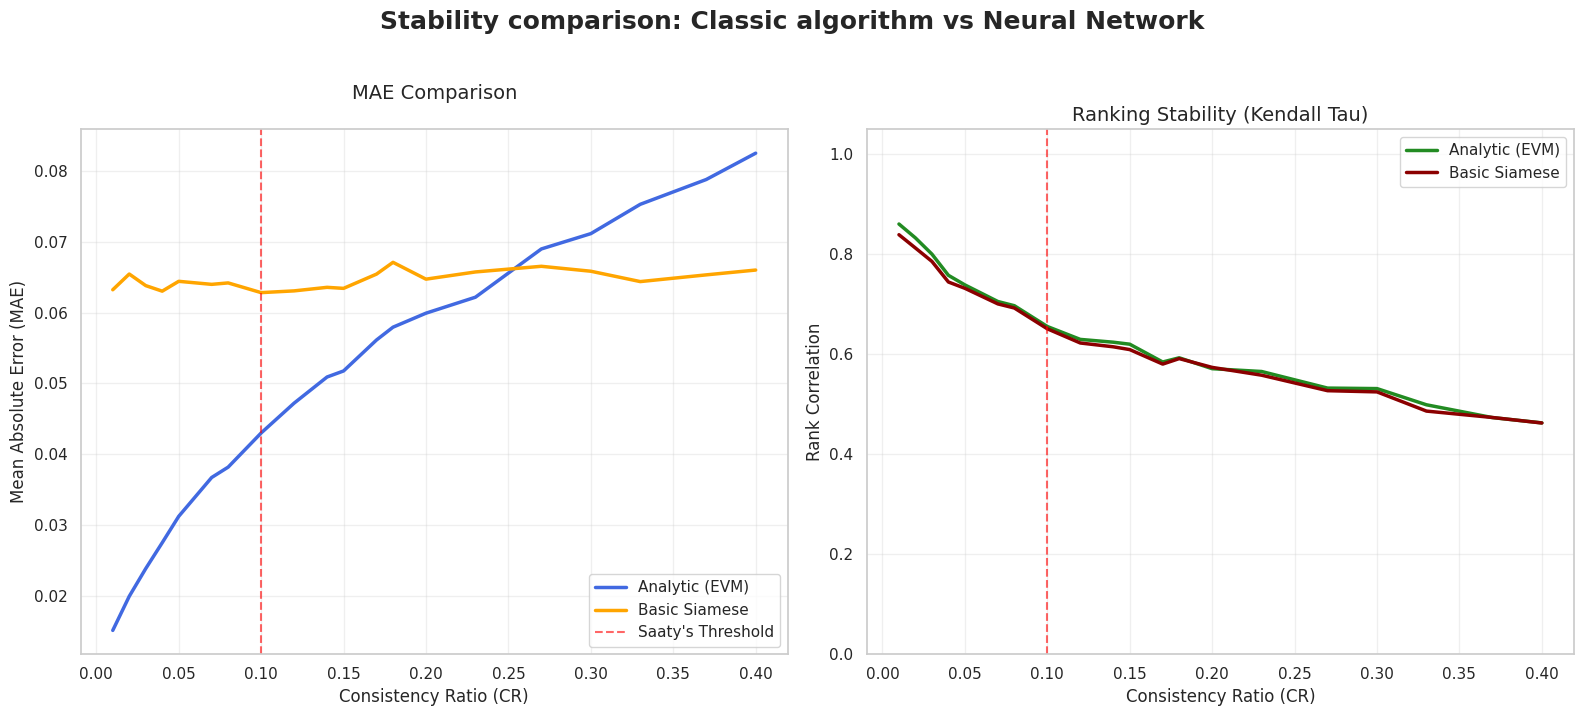

In [9]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

In [12]:
TRAIN_MATRICES_NUM = 1000
VALID_MATRICES_NUM = 100
TEST_MATRICES_NUM = 100

MODEL_TYPE = "siamese"
MODEL_NAME = "advanced_1000m"

model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, history = load_model_weights_history(model, MODEL_TYPE, MODEL_NAME, device)

loader = MatricesLoader()
matrices, weights = load_test_matrices(loader)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    # predicted_priority_vector = predict_single_weights(trained_model, test_matrix, device)
    # evm_priority_vector, _ = evm_solver.compute_single(test_matrix)

    predicted_priority_vectors = predict_batch_weights(trained_model, test_matrices, device)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

History and model: advanced_1000m was loaded from models/siamese
Successfully uploaded 100 noised matrices (level: cr001).
Successfully uploaded 100 noised matrices (level: cr002).
Successfully uploaded 100 noised matrices (level: cr003).
Successfully uploaded 100 noised matrices (level: cr004).
Successfully uploaded 100 noised matrices (level: cr005).
Successfully uploaded 100 noised matrices (level: cr007).
Successfully uploaded 100 noised matrices (level: cr008).
Successfully uploaded 100 noised matrices (level: cr010).
Successfully uploaded 100 noised matrices (level: cr012).
Successfully uploaded 100 noised matrices (level: cr014).
Successfully uploaded 100 noised matrices (level: cr015).
Successfully uploaded 100 noised matrices (level: cr017).
Successfully uploaded 100 noised matrices (level: cr018).
Successfully uploaded 100 noised matrices (level: cr020).
Successfully uploaded 100 noised matrices (level: cr023).
Successfully uploaded 100 noised matrices (level: cr027).
Success

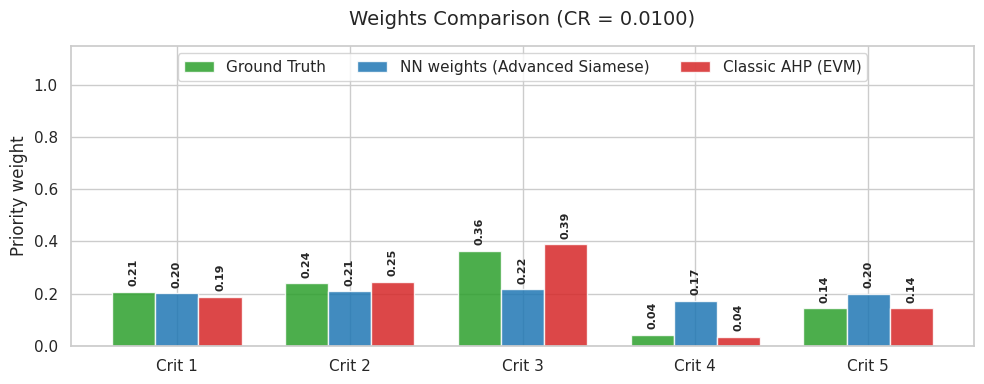

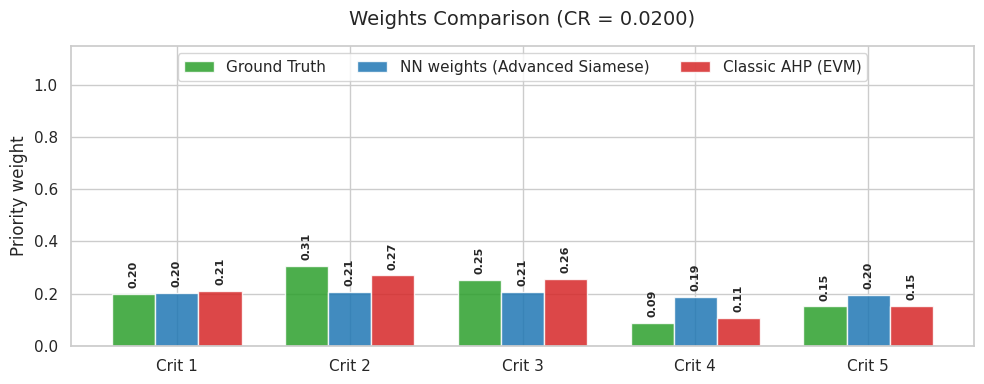

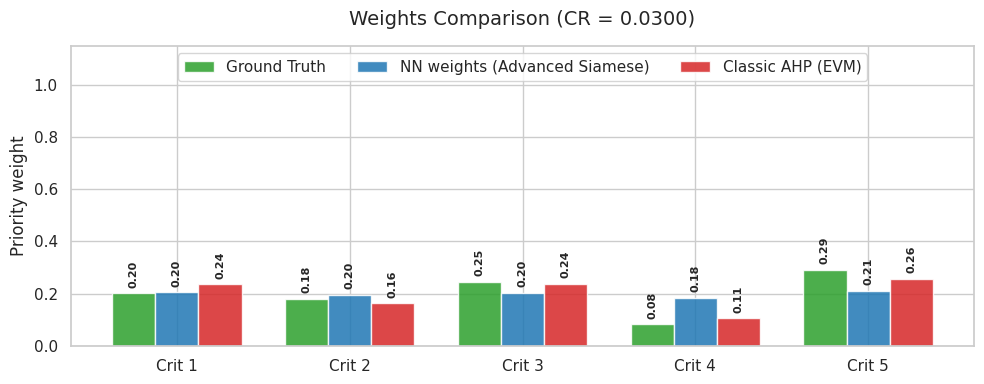

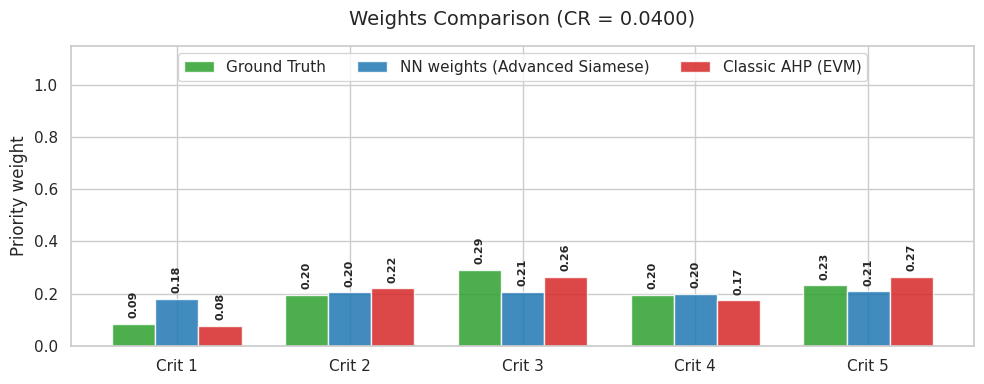

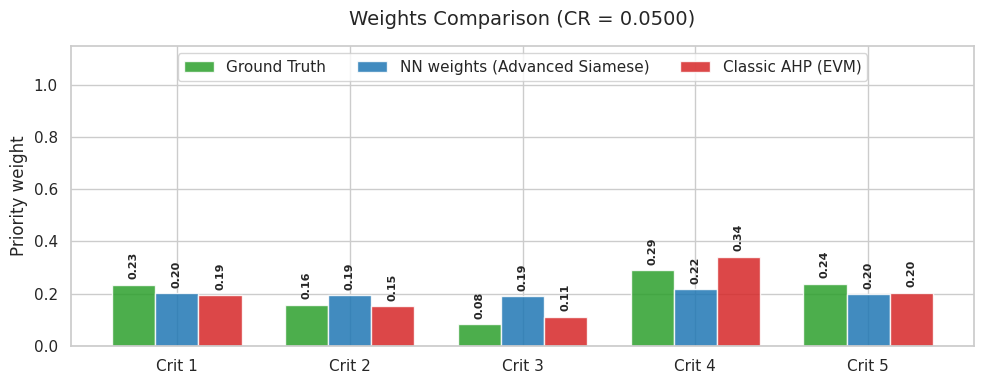

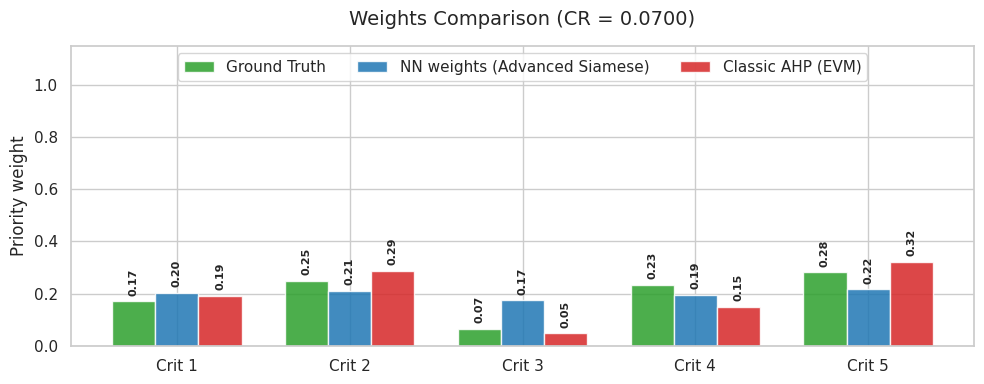

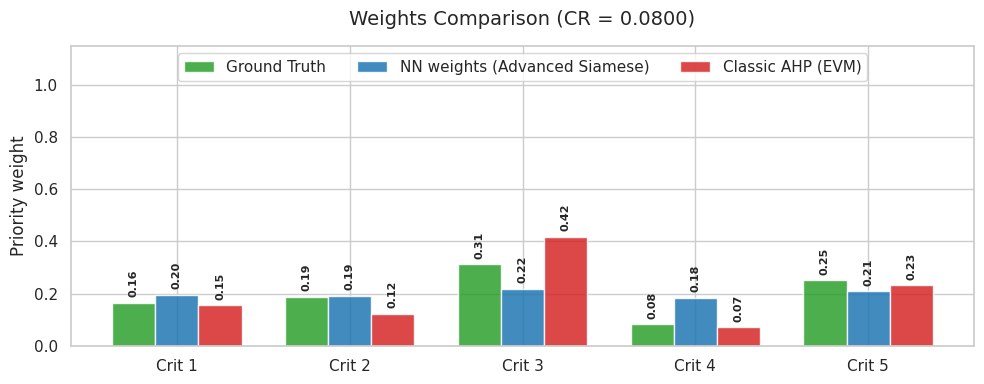

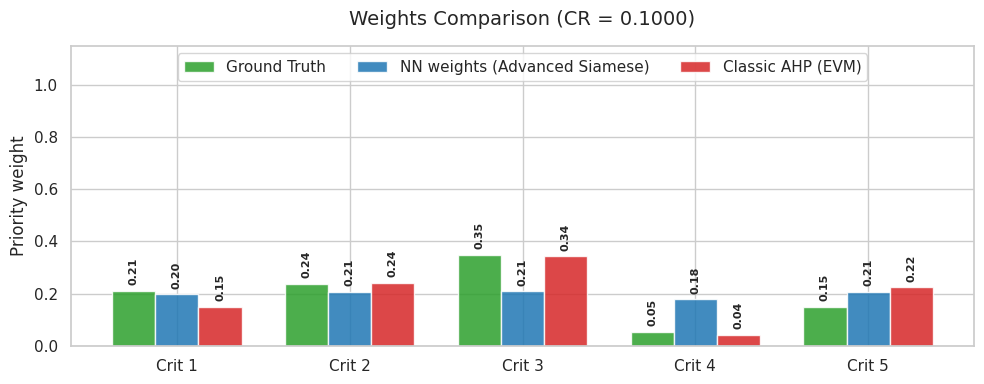

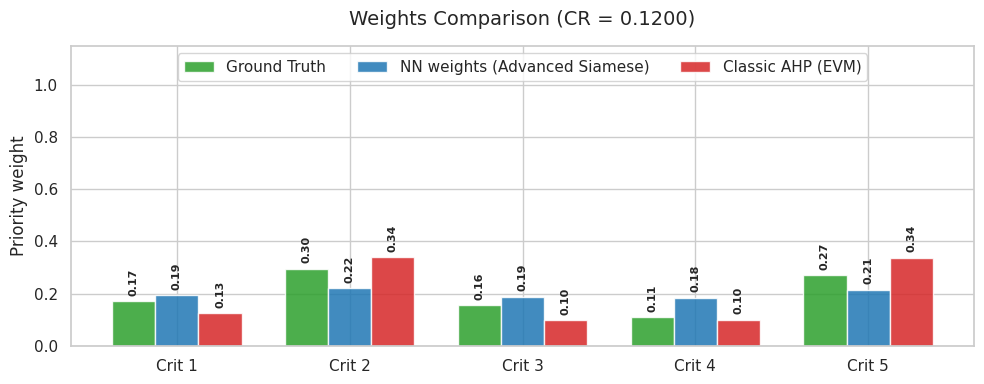

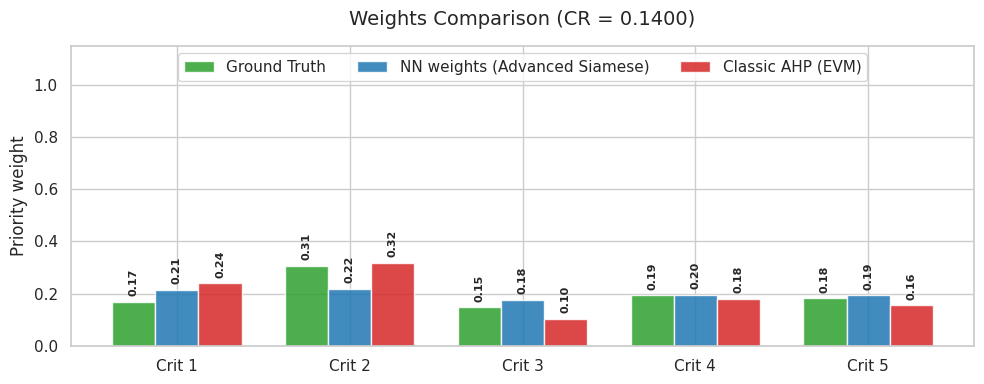

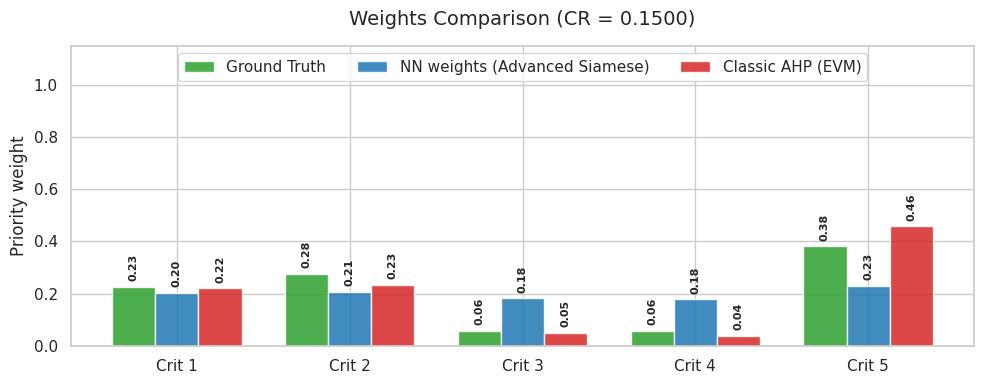

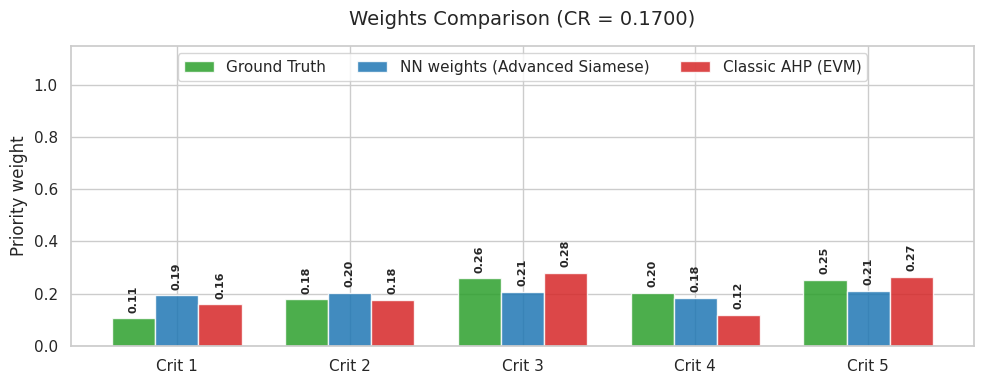

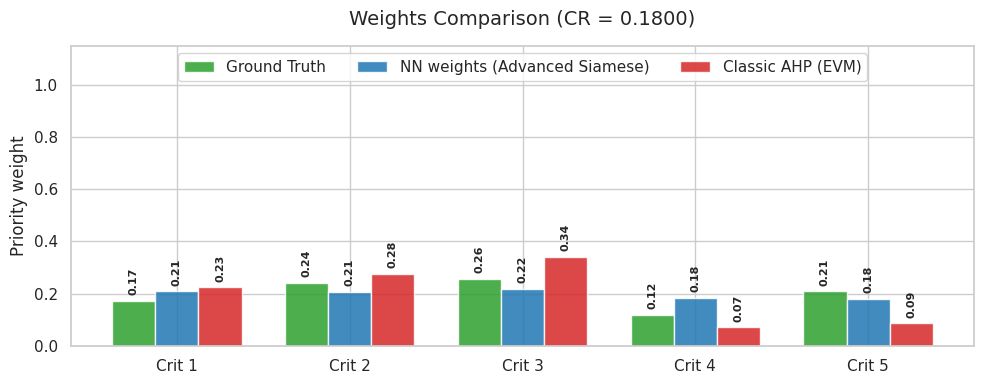

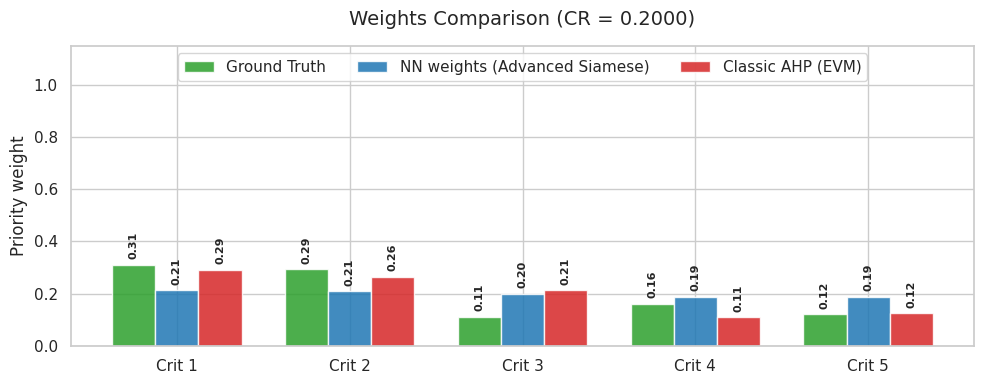

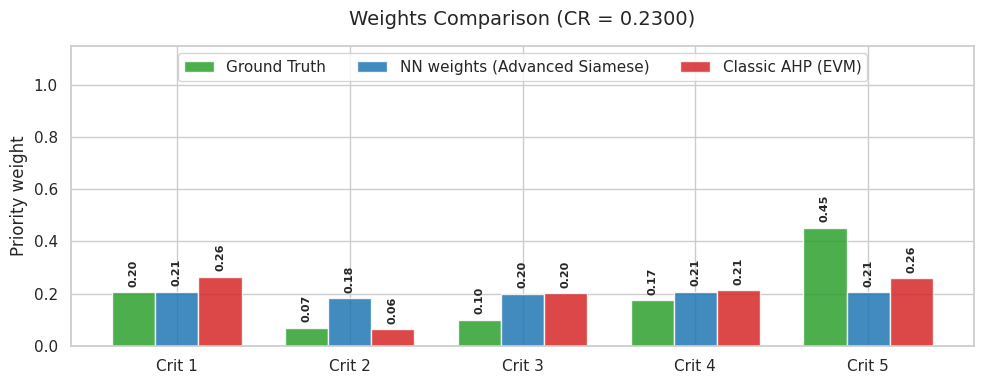

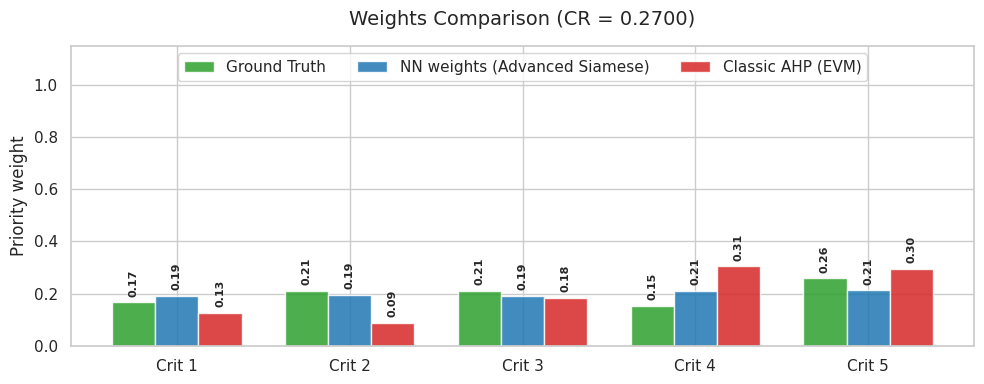

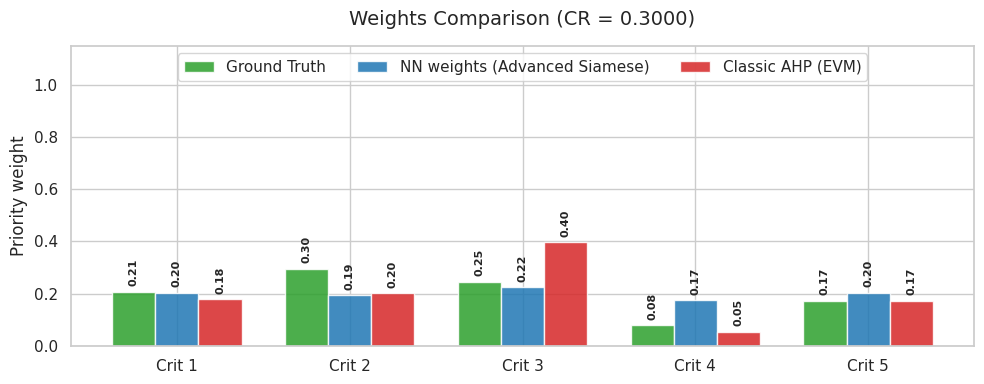

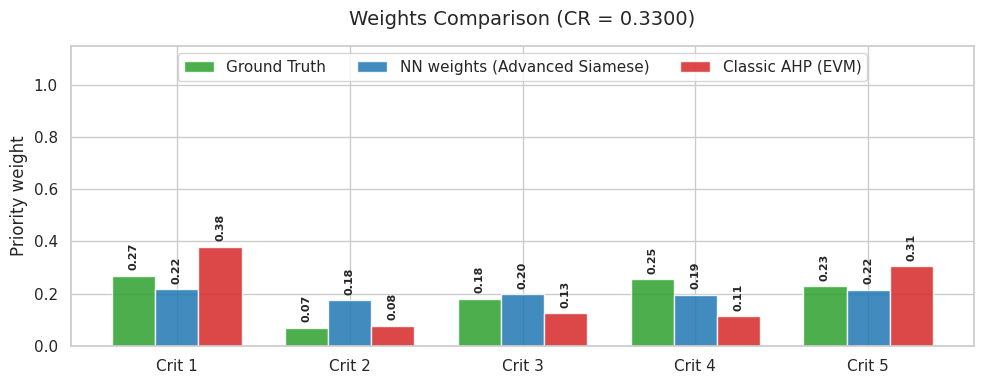

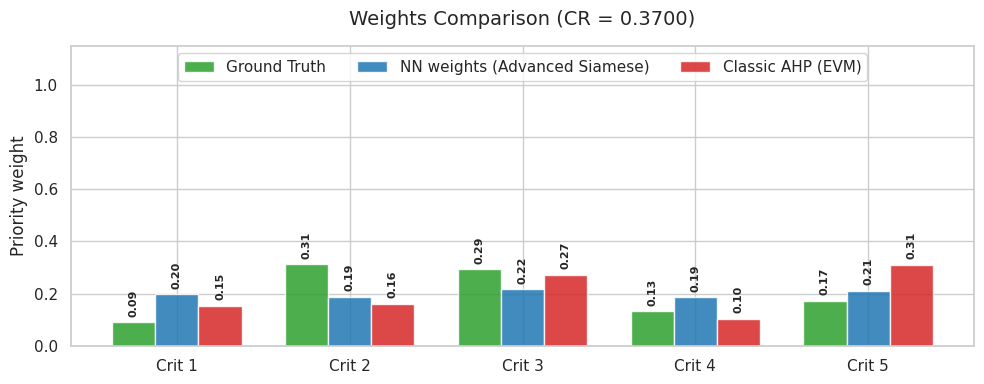

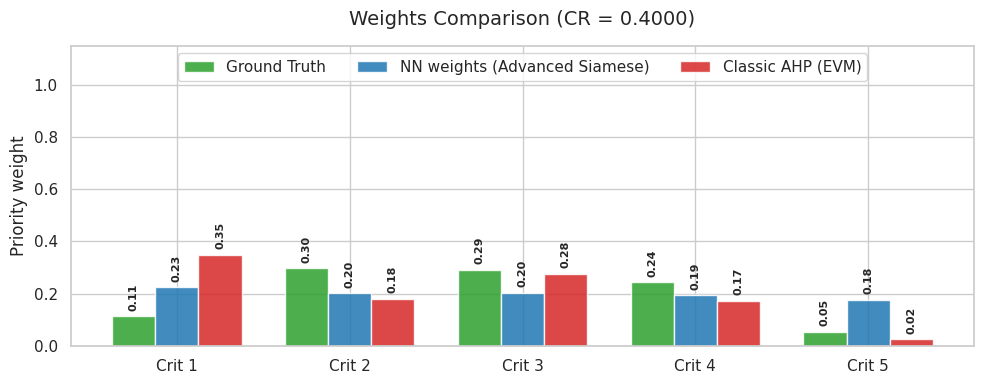

In [13]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 20 consistency rates.
Global mean CR: 0.1630
Global mean MAE (EVM): 0.0502, NN: 0.0648
Global mean Kendall correlation (EVM): 0.6339, NN: 0.6246


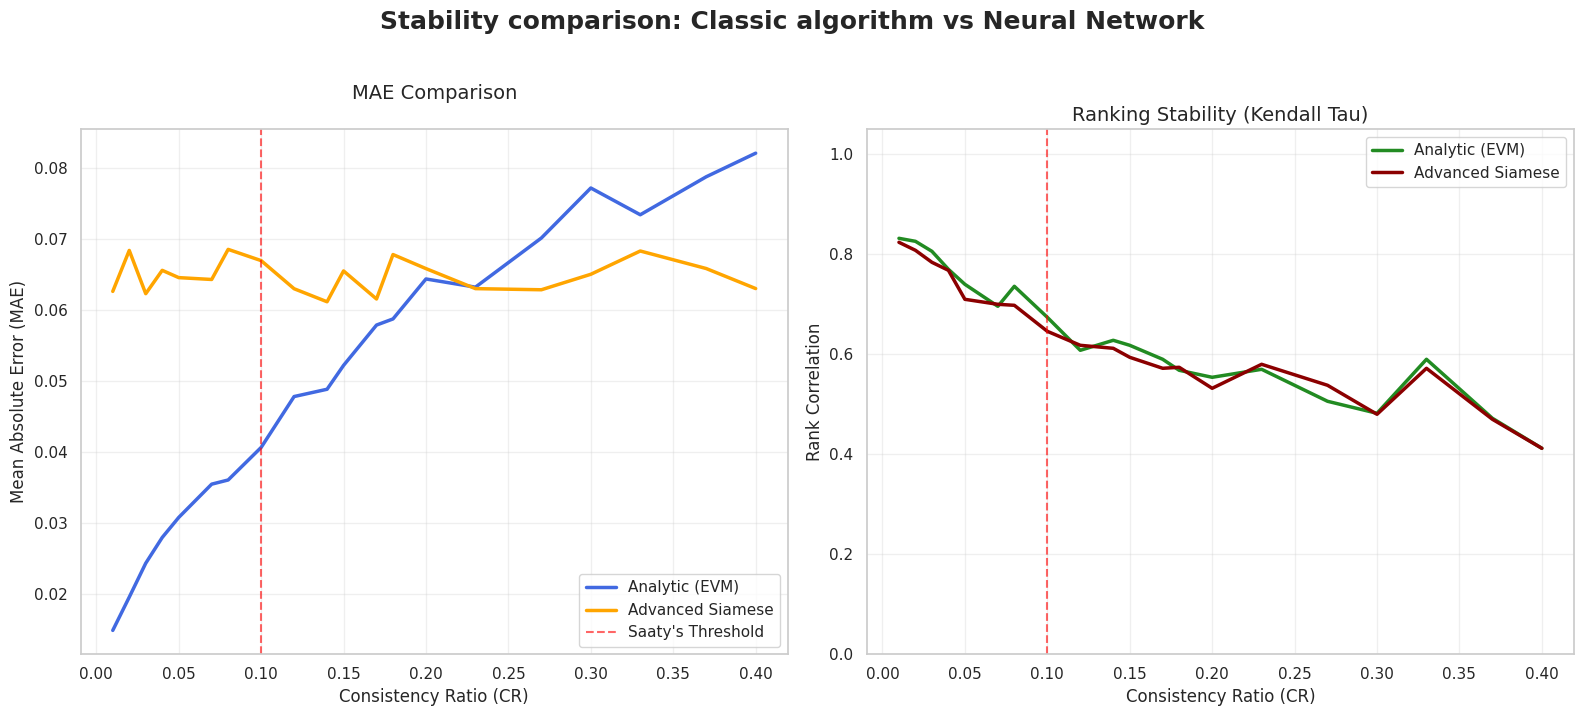

In [14]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)